# Análisis de Caso: Reducción de Dimensionalidad

**Empresa:** VisionData  

**Rol asumido:** Especialista en Ciencia de Datos del equipo de IA  

**Autor:** Manuel Quintana  

**Curso:** FUNDAMENTOS DE CIENCIA DE DATOS  

**Dataset:** Human Activity Recognition (HAR) Dataset  

**Herramientas:** Python, NumPy, Pandas, Scikit-Learn, Matplotlib, PCA, t-SNE

## Objetivo
Aplicar técnicas de reducción de dimensionalidad utilizando métodos como PCA y t-SNE para analizar un conjunto de datos con múltiples variables, con el fin de simplificar su estructura, identificar patrones en los datos y facilitar su visualización en espacios de menor dimensión para su posterior uso en modelos de aprendizaje automático.

## 1. Importación de librerías

In [4]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt

# Escalamiento
from sklearn.preprocessing import StandardScaler

# Reducción de dimensionalidad
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

## 2. Carga del conjunto de datos
En esta sección se carga el dataset *Human Activity Recognition (HAR)*, que contiene múltiples variables numéricas obtenidas a partir de sensores de teléfonos inteligentes. Este conjunto de datos posee un gran número de características (features), lo que lo hace adecuado para aplicar técnicas de reducción de dimensionalidad como PCA y t-SNE con el objetivo de simplificar su estructura y facilitar su análisis y visualización.

Fuente del dataset:  
https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones

In [5]:
# Cargar dataset
data = pd.read_csv("X_train.txt", sep="\s+", header=None)

# Ver dimensiones del dataset
print("Dimensiones del dataset:", data.shape)

# Mostrar primeras filas
data.head()

Dimensiones del dataset: (7352, 561)


,0,1,2,3,4,5,6,7,8,9,...,551,552,553,554,555,556,557,558,559,560
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


In [6]:
# Valores nulos por columna
print("Valores nulos por columna:")
print(data.isnull().sum())

# Total de valores nulos
print("\nTotal de valores nulos:")
print(data.isnull().sum().sum())

Valores nulos por columna:
0      0
1      0
2      0
3      0
4      0
      ..
556    0
557    0
558    0
559    0
560    0
Length: 561, dtype: int64

Total de valores nulos:
0


## 3. Exploración inicial de los datos
En esta sección se realiza una revisión general del conjunto de datos para conocer su estructura, verificar el número de variables y observar estadísticas básicas que permitan comprender mejor la distribución de los datos antes de aplicar técnicas de reducción de dimensionalidad.

In [7]:
# Información general del dataset
data.info()

# Estadísticas descriptivas
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 561 entries, 0 to 560
dtypes: float64(561)
memory usage: 31.5 MB


,0,1,2,3,4,5,6,7,8,9,...,551,552,553,554,555,556,557,558,559,560
count,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,...,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000
mean,0.274488,-0.017695,-0.109141,-0.605438,-0.510938,-0.604754,-0.630512,-0.526907,-0.606150,-0.468604,...,0.125293,-0.307009,-0.625294,0.008684,0.002186,0.008726,-0.005981,-0.489547,0.058593,-0.056515
std,0.070261,0.040811,0.056635,0.448734,0.502645,0.418687,0.424073,0.485942,0.414122,0.544547,...,0.250994,0.321011,0.307584,0.336787,0.448306,0.608303,0.477975,0.511807,0.297480,0.279122
min,-1.000000,-1.000000,-1.000000,-1.000000,-0.999873,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-0.995357,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,0.262975,-0.024863,-0.120993,-0.992754,-0.978129,-0.980233,-0.993591,-0.978162,-0.980251,-0.936219,...,-0.023692,-0.542602,-0.845573,-0.121527,-0.289549,-0.482273,-0.376341,-0.812065,-0.017885,-0.143414
50%,0.277193,-0.017219,-0.108676,-0.946196,-0.851897,-0.859365,-0.950709,-0.857328,-0.857143,-0.881637,...,0.134000,-0.343685,-0.711692,0.009509,0.008943,0.008735,-0.000368,-0.709417,0.182071,0.003181
75%,0.288461,-0.010783,-0.097794,-0.242813,-0.034231,-0.262415,-0.292680,-0.066701,-0.265671,-0.017129,...,0.289096,-0.126979,-0.503878,0.150865,0.292861,0.506187,0.359368,-0.509079,0.248353,0.107659
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.946700,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,1.000000,0.478157,1.000000


## 4. Escalamiento de los datos
Antes de aplicar técnicas de reducción de dimensionalidad, es necesario estandarizar las variables para que todas tengan la misma escala. En esta sección se utiliza el método StandardScaler para transformar los datos de manera que cada variable tenga media 0 y desviación estándar 1, evitando que las variables con mayor magnitud dominen el análisis.

In [8]:
# Crear objeto de escalamiento
scaler = StandardScaler()

# Ajustar y transformar los datos
data_scaled = scaler.fit_transform(data)

# Ver dimensiones
print("Dimensiones de los datos escalados:", data_scaled.shape)

Dimensiones de los datos escalados: (7352, 561)


## 5. Reducción de dimensionalidad con PCA

El Análisis de Componentes Principales (PCA) es una técnica de reducción de dimensionalidad que transforma un conjunto grande de variables en un número menor de componentes principales. Estos componentes capturan la mayor cantidad posible de variabilidad presente en los datos originales.

En este caso, se aplica PCA al dataset escalado con el objetivo de reducir las 561 variables originales a dos componentes principales, lo que permitirá visualizar los datos en un espacio bidimensional y analizar posibles patrones o estructuras.

In [9]:
# Aplicar PCA
pca = PCA(n_components=2)

data_pca = pca.fit_transform(data_scaled)

# Ver dimensiones después de PCA
print("Dimensiones después de PCA:", data_pca.shape)

Dimensiones después de PCA: (7352, 2)


In [10]:
print("Varianza explicada por cada componente:")
print(pca.explained_variance_ratio_)

Varianza explicada por cada componente:
[0.50781172 0.0658068 ]


In [11]:
print("Varianza total explicada:", pca.explained_variance_ratio_.sum())

Varianza total explicada: 0.5736185255809918


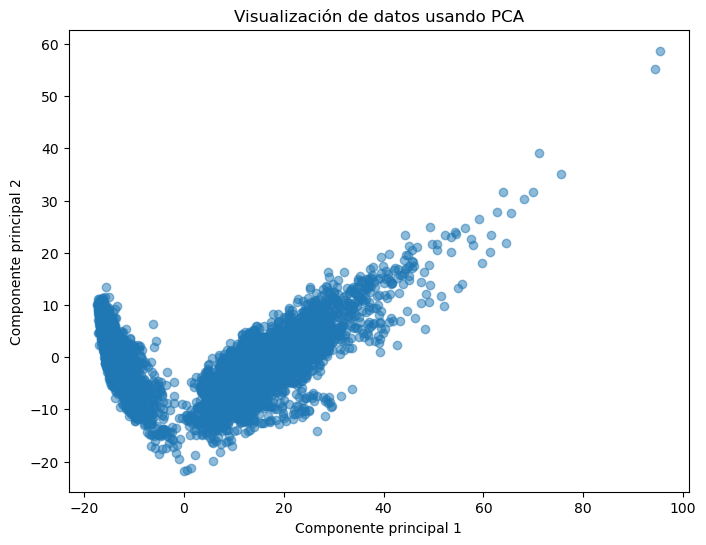

In [12]:
# Crear una figura para el gráfico con tamaño de 8x6 pulgadas
plt.figure(figsize=(8,6))

# Crear un gráfico de dispersión (scatter plot)
# data_pca[:,0] corresponde al primer componente principal (eje X)
# data_pca[:,1] corresponde al segundo componente principal (eje Y)
# alpha controla la transparencia de los puntos
plt.scatter(data_pca[:,0], data_pca[:,1], alpha=0.5)

# Etiqueta del eje X
plt.xlabel("Componente principal 1")

# Etiqueta del eje Y
plt.ylabel("Componente principal 2")

# Título del gráfico
plt.title("Visualización de datos usando PCA")

# Mostrar el gráfico
plt.show()

## 6. Reducción de dimensionalidad con t-SNE

t-SNE (t-Distributed Stochastic Neighbor Embedding) es una técnica de reducción de dimensionalidad no lineal utilizada principalmente para la visualización de datos de alta dimensión. A diferencia de PCA, que busca maximizar la varianza global de los datos, t-SNE se enfoca en preservar las relaciones de vecindad entre observaciones.

En esta sección se aplica t-SNE al conjunto de datos escalado para reducir las 561 variables originales a dos dimensiones, permitiendo visualizar posibles agrupaciones o patrones en los datos.

In [13]:
# Crear el modelo t-SNE reduciendo los datos a 2 dimensiones
tsne = TSNE(n_components=2, random_state=42)

# Aplicar t-SNE a los datos escalados
data_tsne = tsne.fit_transform(data_scaled)

# Ver dimensiones del resultado
print("Dimensiones después de t-SNE:", data_tsne.shape)

Dimensiones después de t-SNE: (7352, 2)


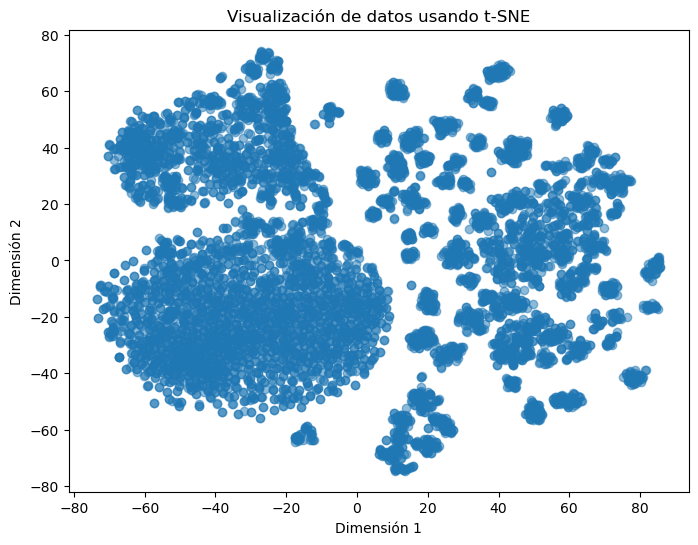

In [14]:
# Crear figura
plt.figure(figsize=(8,6))

# Gráfico de dispersión con los datos reducidos por t-SNE
plt.scatter(data_tsne[:,0], data_tsne[:,1], alpha=0.5)

# Etiquetas de los ejes
plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")

# Título del gráfico
plt.title("Visualización de datos usando t-SNE")

# Mostrar gráfico
plt.show()

## 7. Análisis de resultados

Al comparar los resultados obtenidos con PCA y t-SNE se observan diferencias importantes en la estructura de los datos.

En el caso de PCA, los datos se proyectan en dos componentes principales que capturan la mayor parte de la varianza del conjunto de datos. El gráfico muestra una nube continua de puntos con una tendencia principal, lo que indica que PCA preserva la estructura global de los datos, pero no necesariamente separa claramente posibles agrupaciones.

Por otro lado, al aplicar t-SNE se observan múltiples grupos o nubes de puntos más compactas y separadas entre sí. Esto ocurre porque t-SNE preserva mejor las relaciones locales entre observaciones, lo que permite visualizar patrones o agrupaciones que no son tan evidentes con métodos lineales como PCA.

## 8. Selección de técnica

Para presentar insights al equipo de marketing, se elegiría la técnica t-SNE, ya que permite visualizar de manera más clara los posibles grupos o segmentos dentro de los datos.

A diferencia de PCA, que preserva la varianza global del conjunto de datos, t-SNE facilita la identificación de patrones locales y agrupaciones más definidas. Esto resulta especialmente útil en contextos de marketing, donde es importante identificar segmentos de clientes o comportamientos similares.

Sin embargo, PCA también es una herramienta valiosa como paso previo, debido a su menor costo computacional y su capacidad para reducir la dimensionalidad de manera eficiente.

## 9. Conclusiones

En este análisis se aplicaron técnicas de reducción de dimensionalidad sobre un conjunto de datos con 561 variables, utilizando PCA y t-SNE. PCA permitió reducir la dimensionalidad preservando la mayor parte de la variabilidad de los datos, facilitando una visualización general de su estructura.

Por su parte, t-SNE mostró una mejor separación entre grupos de observaciones, permitiendo identificar posibles patrones o agrupaciones dentro del conjunto de datos. Esto demuestra que las técnicas de reducción de dimensionalidad son herramientas útiles para explorar datasets de alta dimensión y facilitar su interpretación visual.